In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
import time
from optic.models.tx import pamTransmitter
from optic.models.devices import photodiode, edfa, dac, adc, mzm, basicLaserModel
from optic.dsp.equalization import dfe, ffe
from optic.models.channels import linearFiberChannel, awgn
from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray, grayMapping , demodulateGray
from optic.comm.metrics import bert, fastBERcalc, theoryBER
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate ,signalPower
from optic.utils import parameters, dBm2W, lin2dB
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

In [7]:
from AnalyticalSNR import (
    superGauss,
    SNR_Folding,
    SNR_DFE,
    SNR_FFE,
    calc_S_th,
    calc_S_th_opticompy,
    calc_S_shot,
    calc_S_shot_opticompy,
    calc_S_RIN,
    calc_S_RIN_opticompy,
    calc_S_ADC,
    calc_S_ADC_opticompy,
    calc_S_N,
    calculate_oma_outer,
    get_spectral_snr,
    ber_from_snr_m_pam,
    calculate_ps2
)

In [8]:
def H_SMF_optical(f, DL_ps_nm, fc):
    """
    Função de transferência ÓTICA exata da fibra (Equação 12)
    DL_ps_nm: Dispersão acumulada D*L em ps/nm
    """
    c = 299792458
    # Conversão de ps/nm para s/m (Sistema Internacional): 1 ps/nm = 1e-12 s / 1e-9 m = 1e-3 s/m
    DL_SI = DL_ps_nm * 1e-3 
    return np.exp(1j * np.pi * c * DL_SI * (f/fc)**2)

def H_CD(f, D_L, fc):
    """
    Obtains the frequency response of chromatic disperion of a linear fiber

    param:
        f(np.array): frequency vector in Hz
        D(float): CD parameter of the fiber
        L(float): Length of the fiber channel
        fc(float): Central frequency of optical signal
    returns:
        H_cd(np.array): Frequency coefficients of linear fiber response
    """
    c = 299792458
    H_cd = np.cos(np.pi*c*D_L* (f/fc)**2)

    return H_cd

Iniciando varredura analítica 2D. Aguarde...


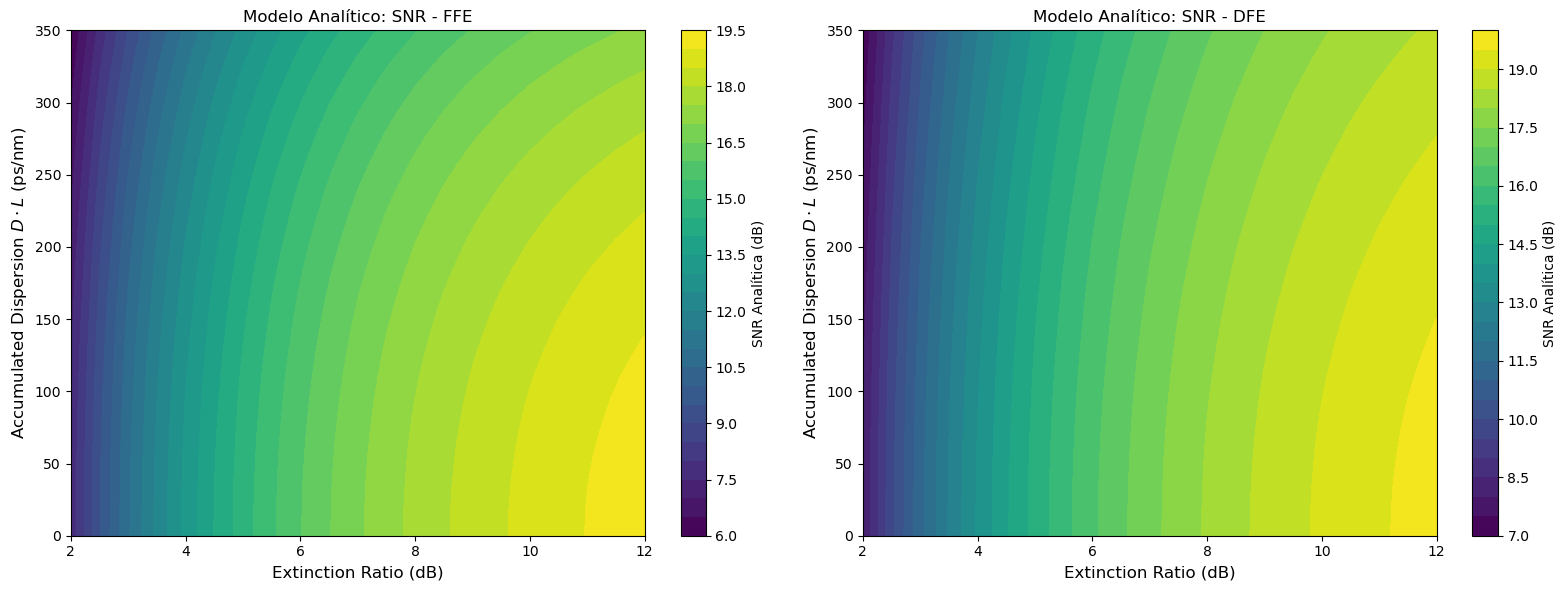

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 0. FUNÇÃO DA DISPERSÃO CROMÁTICA (Com conversão de S.I.)
# =================================================================
def H_CD(f, D_L_ps_nm, fc):
    c = 299792458
    # A conversão de ps/nm para s/m (1e-3) é vital para a fórmula não estourar
    DL_SI = D_L_ps_nm * 1e-3 
    return np.cos(np.pi * c * DL_SI * (f / fc)**2)

# =================================================================
# 1. PARÂMETROS GLOBAIS E CONSTANTES
# =================================================================
pTx_dBm = 0
pTx_W = 10**(pTx_dBm/10) * 1e-3
R = 1.0
N0 = 2e-19
RIN = -140
M = 4
Rs = 25e9
Tb = 1 / (Rs * 2)
TX_Ts = 1 / Rs

c_speed = 299792458
lambda_c = 1310e-9 
fc = c_speed / lambda_c

SIM_N = 10000        
SIM_fmax = 3e12      

# Eixos de frequência
f = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)

# Resposta do Pulso e Ruídos Fixos (Base)
Pulse = np.sinc(2 * Tb * f)
S_th = calc_S_th(N0, f)
S_shot = calc_S_shot(pTx_W, R, 1, 1, f) 

# =================================================================
# 2. PREPARAÇÃO DA VARREDURA 2D (Eixos do Gráfico)
# =================================================================
# Substituímos a varredura de banda por ER e D*L
ER_range_dB = np.linspace(2, 12, 21)        # Eixo X: 2 a 12 dB
DL_range_ps_nm = np.linspace(0, 350, 20)    # Eixo Y: 0 a 350 ps/nm

B_3dB = 0.4 * Rs  # Para esse gráfico, o artigo fixa a banda eletrônica!
n_order = 1       # Assumindo filtro supergaussiano de 1ª ordem

# Matrizes para guardar o eixo Z (Cores/SNR)
snr_ffe_matrix = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))
snr_dfe_matrix = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))

print("Iniciando varredura analítica 2D. Aguarde...")

# =================================================================
# 3. LOOP PRINCIPAL (ER e Dispersão)
# =================================================================
for col, er_db in enumerate(ER_range_dB):
    # Recalcula OMA e RIN para cada nível de ER
    OMA_outer = calculate_oma_outer(pTx_W, er_db)
    Ps2 = calculate_ps2(pTx_W, M, OMA_outer)
    S_RIN_global = calc_S_RIN(Ps2, RIN, f)
    
    for row, dl in enumerate(DL_range_ps_nm):
        
        # 1. Resposta do Canal (Elétrico + Dispersão)
        H_ch_base = superGauss(f, n=n_order, B_3dB=B_3dB)
        H_cd_ana = H_CD(f, dl, fc)
        
        # A MÁGICA ACONTECE AQUI: O canal total engloba a dispersão matemática
        H_ch_total = H_ch_base * H_cd_ana
        H_ch_sq = np.abs(H_ch_total)**2
        
        # 2. Ruído Total Global 
        S_N_total = calc_S_N(S_RIN_global, S_shot, S_th, 0, H_ch_sq, False)
        
        # 3. SNR Espectral (Global)
        S_N_f = get_spectral_snr(f, OMA_outer, Rs, Pulse, H_ch_total, S_N_total)
        
        # Prevenindo Zeros Absolutos para o Log10 não quebrar
        S_N_f = np.maximum(np.nan_to_num(S_N_f, nan=1e-30), 1e-30)
        
        # 4. Folding e Integrais Globais
        SNR_folded = SNR_Folding(S_N_f, f, mu=2, Rs=Rs)
        safe_SNR = np.maximum(np.abs(SNR_folded), 1e-30) # Evita divide by zero
        SNR_f_interp = 10**(np.interp(f_int, f, 10 * np.log10(safe_SNR)) / 10)
        
        # Equalizadores
        snr_ffe_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp + 1), x=f_int)) - 1
        snr_dfe_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp + 1), x=f_int)) - 1
        
        # Armazena os resultados na matriz em dB
        snr_ffe_matrix[row, col] = 10 * np.log10(snr_ffe_lin)
        snr_dfe_matrix[row, col] = 10 * np.log10(snr_dfe_lin)

# =================================================================
# 4. PLOTAGEM DO MAPA DE CONTORNO
# =================================================================
X, Y = np.meshgrid(ER_range_dB, DL_range_ps_nm)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Mapa FFE
cp1 = ax1.contourf(X, Y, snr_ffe_matrix, levels=30, cmap='viridis')
fig.colorbar(cp1, ax=ax1, label='SNR Analítica (dB)')
ax1.set_title('Modelo Analítico: SNR - FFE')
ax1.set_xlabel('Extinction Ratio (dB)', fontsize=12)
ax1.set_ylabel('Accumulated Dispersion $D \cdot L$ (ps/nm)', fontsize=12)

# Mapa DFE
cp2 = ax2.contourf(X, Y, snr_dfe_matrix, levels=30, cmap='viridis')
fig.colorbar(cp2, ax=ax2, label='SNR Analítica (dB)')
ax2.set_title('Modelo Analítico: SNR - DFE')
ax2.set_xlabel('Extinction Ratio (dB)', fontsize=12)
ax2.set_ylabel('Accumulated Dispersion $D \cdot L$ (ps/nm)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
import time
import scipy.constants as const

# =================================================================
# 0. FUNÇÕES DA DISPERSÃO
# =================================================================
def H_CD(f, D_L_ps_nm, fc):
    c = 299792458
    DL_SI = D_L_ps_nm * 1e-3 
    return np.cos(np.pi * c * DL_SI * (f / fc)**2)

def H_SMF_optical(f, D_L_ps_nm, fc):
    c = 299792458
    DL_SI = D_L_ps_nm * 1e-3
    return np.exp(1j * np.pi * c * DL_SI * (f / fc)**2)

# =================================================================
# 1. PARÂMETROS GLOBAIS E EIXOS DA VARREDURA
# =================================================================
Rs = 25e9
P_avg_alvo = 1.0 # mW
pTx_W = P_avg_alvo * 1e-3
M = 4
N0 = 2e-19
RIN = -140
c_speed = 299792458
lambda_c = 1310e-9 
fc = c_speed / lambda_c
kB = const.value("Boltzmann constant")
T_kelvin = 70 + 273.15

DAC_ADC = True

SpS_TX = 2 if DAC_ADC else 16 
Fs = Rs * SpS_TX
n_dac = 8 if DAC_ADC else 1
Res = 8
sim_Fs = n_dac * Fs
TX_Ts = 1 / Rs

B_3dB = 0.4 * Rs
n_order = 1 
SIM_N = 10000

# Eixos da Varredura
ER_range_dB = np.linspace(2, 12, 11)        
DL_range_ps_nm = np.linspace(0, 350, 20)    

# Matrizes para armazenar TUDO
SNR_FFE_ana_matrix = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))
SNR_FFE_sim_matrix = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))
SNR_DFE_ana_matrix = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))
SNR_DFE_sim_matrix = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))

# Eixos de frequência para o modelo analítico
SIM_fmax = 3e12 
f_analytical = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)
Tb = 1 / (Rs * 2)
Pulse_f = np.sinc(2 * Tb * f_analytical)

print(f"Iniciando Varredura. Modo DAC_ADC = {DAC_ADC}. Aguarde...")
start_time = time.time()

# =================================================================
# 2. LOOP PRINCIPAL
# =================================================================
for col, er_db in enumerate(ER_range_dB):
    print(f"\n[{col+1}/{len(ER_range_dB)}] Processando ER = {er_db:.2f} dB")
    
    # --- TRANSMISSOR (SIMULAÇÃO) ---
    paramBits = parameters()
    paramBits.nBits = 500000  
    paramBits.mode = 'random'
    paramBits.seed = 7
    bits = bitSource(paramBits)

    symb_Tx = modulateGray(bits, M, 'pam')
    symb_Tx_up = upsample(symb_Tx, SpS_TX)

    paramPulse = parameters()
    paramPulse.pulseType = 'rect'
    paramPulse.SpS = SpS_TX
    pulse = pulseShape(paramPulse)
    
    signal_Tx_base = firFilter(pulse, symb_Tx_up)
    
    # --- CÁLCULOS EXATOS PARA O MODELO ANALÍTICO ---
    ER_lin = 10**(er_db/10)
    x = (ER_lin - 1) / (ER_lin + 1)
    
    OMA_outer = calculate_oma_outer(pTx_W, er_db)
    Ps2 = calculate_ps2(pTx_W, M, OMA_outer)
    S_RIN_global = calc_S_RIN(Ps2, RIN, f_analytical)
    S_th_array = calc_S_th(N0, f_analytical)
    S_shot_array = calc_S_shot(pTx_W, 1.0, 1, 1, f_analytical)
    
    # Continuar Transmissor (Simulação)
    paramMZM = parameters()
    paramMZM.Vpi = 8
    paramMZM.Vb = -paramMZM.Vpi/2
    Vpp_calculado = (2 * paramMZM.Vpi / np.pi) * np.arcsin(x)
    
    paramDAC = parameters()
    paramDAC.inFs = Fs            
    paramDAC.outFs = sim_Fs       
    paramDAC.nBits = Res         
    paramDAC.ENOB = paramDAC.nBits          
    paramDAC.Vpp = Vpp_calculado          
    paramDAC.AIF = True  
    
    if DAC_ADC:
        signal_Tx_DAC = dac(signal_Tx_base, paramDAC)
    else:
        paramDAC.outFs = Fs
        pico_sinal = np.max(np.abs(signal_Tx_base))
        signal_Tx_DAC = (signal_Tx_base / pico_sinal) * (Vpp_calculado / 2)
        
    E_unit = mzm(1.0 + 0j, signal_Tx_DAC, paramMZM)
    P_avg_unit = np.mean(np.abs(E_unit)**2) 
    Pi_dBm_calibrado = 10 * np.log10(P_avg_alvo / P_avg_unit)
    
    paramLaser = parameters()
    paramLaser.P = Pi_dBm_calibrado
    paramLaser.lw = 0
    paramLaser.RIN_var = 10**(RIN/10) 
    paramLaser.Fs = paramDAC.outFs
    paramLaser.Ns = len(signal_Tx_DAC)
    laserTx = basicLaserModel(paramLaser)
    
    signal_optTx = mzm(laserTx, signal_Tx_DAC, paramMZM)
    signal_optTx_fft = fft(signal_optTx)
    f_sim = fftfreq(len(signal_optTx), d=1/sim_Fs)
    
    # =================================================================
    # 3. LOOP INTERNO (Dispersão Acumulada D*L)
    # =================================================================
    for row, dl in enumerate(DL_range_ps_nm):
        
        # --- MODELO ANALÍTICO (Seu código incorporado) ---
        H_ch_base_ana = superGauss(f_analytical, n=n_order, B_3dB=B_3dB)
        H_cd_ana = H_CD(f_analytical, dl, fc)
        H_ch_total_ana = H_ch_base_ana * H_cd_ana
        H_ch_sq_ana = np.abs(H_ch_total_ana)**2
        
        S_N_total = (np.abs(Pulse)**2)*calc_S_N(S_RIN_global, S_shot_array, S_th_array, 0, H_ch_sq_ana, False)
        S_N_f = (np.abs(Pulse)**2)*get_spectral_snr(f_analytical, OMA_outer, Rs, Pulse_f, H_ch_total_ana, S_N_total)
        S_N_f = np.maximum(np.nan_to_num(S_N_f, nan=1e-30), 1e-30)
        
        SNR_folded = SNR_Folding(S_N_f, f_analytical, mu=2, Rs=Rs)
        safe_SNR = np.maximum(np.abs(SNR_folded), 1e-30) 
        SNR_f_interp = 10**(np.interp(f_int, f_analytical, 10 * np.log10(safe_SNR)) / 10)
        
        snr_ffe_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp + 1), x=f_int)) - 1
        snr_dfe_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp + 1), x=f_int)) - 1
        
        SNR_FFE_ana_matrix[row, col] = 10 * np.log10(snr_ffe_lin)
        SNR_DFE_ana_matrix[row, col] = 10 * np.log10(snr_dfe_lin)
        
        # --- SIMULAÇÃO ---
        H_smf_opt = H_CD(f_sim, dl, fc)
        signal_optRx_fiber = ifft(signal_optTx_fft * H_smf_opt)
        
        paramPD = parameters()
        paramPD.R = 1.0
        paramPD.Id = 1e-9                                    
        paramPD.RL = (4 * kB * T_kelvin) / N0 
        paramPD.Fs = sim_Fs
        paramPD.ideal = False
        paramPD.shotNoise = True
        paramPD.thermalNoise = True
        paramPD.currentSaturation = False
        paramPD.bandwidthLimitation = False
        paramPD.seed = 7
        PD_signalRx = photodiode(signal_optRx_fiber, paramPD)
        
        H_ch_sim = superGauss(f_sim, n=n_order, B_3dB=B_3dB)
        PD_signalRx_filtered = np.real(ifft(fft(PD_signalRx) * H_ch_sim))
        
        if DAC_ADC:
            paramAdc = parameters()
            paramAdc.inFs = sim_Fs
            paramAdc.outFs = Fs
            paramAdc.nBits = paramDAC.nBits
            paramAdc.ENOB = paramDAC.ENOB
            paramAdc.Vmax = np.max(np.abs(PD_signalRx_filtered))
            paramAdc.Vmin = -paramAdc.Vmax
            paramAdc.AAF = False 
            
            sigRx = adc(PD_signalRx_filtered, paramAdc)
            sigRx = firFilter(pulse, sigRx) 
        else:
            sigRx_alta_res = firFilter(pulse, PD_signalRx_filtered) 
            fator_decimacao = SpS_TX // 2
            sigRx = sigRx_alta_res[::fator_decimacao]
        
        nTrain = 50000
        
        paramDFE = parameters()
        paramDFE.nTapsFF = 30
        paramDFE.nTapsFB = 30
        paramDFE.SpS = 2
        paramDFE.mu = 1e-3
        paramDFE.nTrain = nTrain
        paramDFE.M = M
        paramDFE.trainingMode = "fulltime"
        outDFE, _, _, _ = dfe(sigRx, symb_Tx, paramDFE)
        outDFE = pnorm(outDFE)
        
        paramFFE = parameters()
        paramFFE.nTaps = 200
        paramFFE.mu = 1e-3
        paramFFE.nTrain = nTrain
        paramFFE.SpS = 2
        paramFFE.M = M
        paramFFE.trainingMode = "fulltime"
        outFFE, _, _ = ffe(sigRx, symb_Tx, paramFFE)
        outFFE = pnorm(outFFE)

        discard = nTrain
        _, _, snr_ffe_sim = fastBERcalc(outFFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')
        _, _, snr_dfe_sim = fastBERcalc(outDFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')
        
        SNR_FFE_sim_matrix[row, col] = snr_ffe_sim[0]
        SNR_DFE_sim_matrix[row, col] = snr_dfe_sim[0]

print(f"\nTempo Total: {(time.time() - start_time)/60:.2f} min")

# =================================================================
# 4. CÁLCULO DOS ERROS E PLOTAGEM SEPARADA
# =================================================================
delta_FFE = np.abs(SNR_FFE_sim_matrix - SNR_FFE_ana_matrix)
delta_DFE = np.abs(SNR_DFE_sim_matrix - SNR_DFE_ana_matrix)

X, Y = np.meshgrid(ER_range_dB, DL_range_ps_nm)

# FIGURA 1: SNR ABSOLUTA - FFE
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))
fig1.suptitle('Desempenho FFE Absoluto (dB)', fontsize=16)

c0 = axes1[0].contourf(X, Y, SNR_FFE_ana_matrix, levels=20, cmap='viridis')
fig1.colorbar(c0, ax=axes1[0])
axes1[0].set_title('Modelo Analítico')

c1 = axes1[1].contourf(X, Y, SNR_FFE_sim_matrix, levels=20, cmap='viridis')
fig1.colorbar(c1, ax=axes1[1])
axes1[1].set_title('Simulação OpticommPy')

for ax in axes1:
    ax.set_xlabel('Extinction Ratio (dB)')
    ax.set_ylabel('Dispersão Acumulada $D \cdot L$ (ps/nm)')

# FIGURA 2: SNR ABSOLUTA - DFE
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle('Desempenho DFE Absoluto (dB)', fontsize=16)

c2 = axes2[0].contourf(X, Y, SNR_DFE_ana_matrix, levels=20, cmap='viridis')
fig2.colorbar(c2, ax=axes2[0])
axes2[0].set_title('Modelo Analítico')

c3 = axes2[1].contourf(X, Y, SNR_DFE_sim_matrix, levels=20, cmap='viridis')
fig2.colorbar(c3, ax=axes2[1])
axes2[1].set_title('Simulação OpticommPy')

for ax in axes2:
    ax.set_xlabel('Extinction Ratio (dB)')
    ax.set_ylabel('Dispersão Acumulada $D \cdot L$ (ps/nm)')

# FIGURA 3: ERRO ABSOLUTO (DELTA SNR) SEPARADO
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))
fig3.suptitle('Erro Absoluto $\Delta$SNR (dB): |Simulação - Modelo|', fontsize=16, fontweight='bold')

c4 = axes3[0].contourf(X, Y, delta_FFE, levels=20, cmap='Reds')
fig3.colorbar(c4, ax=axes3[0])
axes3[0].set_title('$\Delta$SNR - FFE')

c5 = axes3[1].contourf(X, Y, delta_DFE, levels=20, cmap='Reds')
fig3.colorbar(c5, ax=axes3[1])
axes3[1].set_title('$\Delta$SNR - DFE')

for ax in axes3:
    ax.set_xlabel('Extinction Ratio (dB)')
    ax.set_ylabel('Dispersão Acumulada $D \cdot L$ (ps/nm)')

plt.tight_layout()
plt.show()

Iniciando Varredura. Modo DAC_ADC = True. Aguarde...

[1/11] Processando ER = 2.00 dB


Exception ignored on calling ctypes callback function <function ExecutionEngine._raw_object_cache_notify at 0x0000022F7CE77A60>:
Traceback (most recent call last):
  File "c:\Users\jezrael.filgueiras\anaconda3\Lib\site-packages\llvmlite\binding\executionengine.py", line 178, in _raw_object_cache_notify
    def _raw_object_cache_notify(self, data):
KeyboardInterrupt: 


Iniciando Varredura. Aguarde...

>> Processando RIN = -150 dB/Hz

>> Processando RIN = -145 dB/Hz

>> Processando RIN = -140 dB/Hz

>> Processando RIN = -135 dB/Hz

>> Processando RIN = -130 dB/Hz

>> Processando RIN = -125 dB/Hz

>> Processando RIN = -120 dB/Hz

Tempo Total: 3.31 min


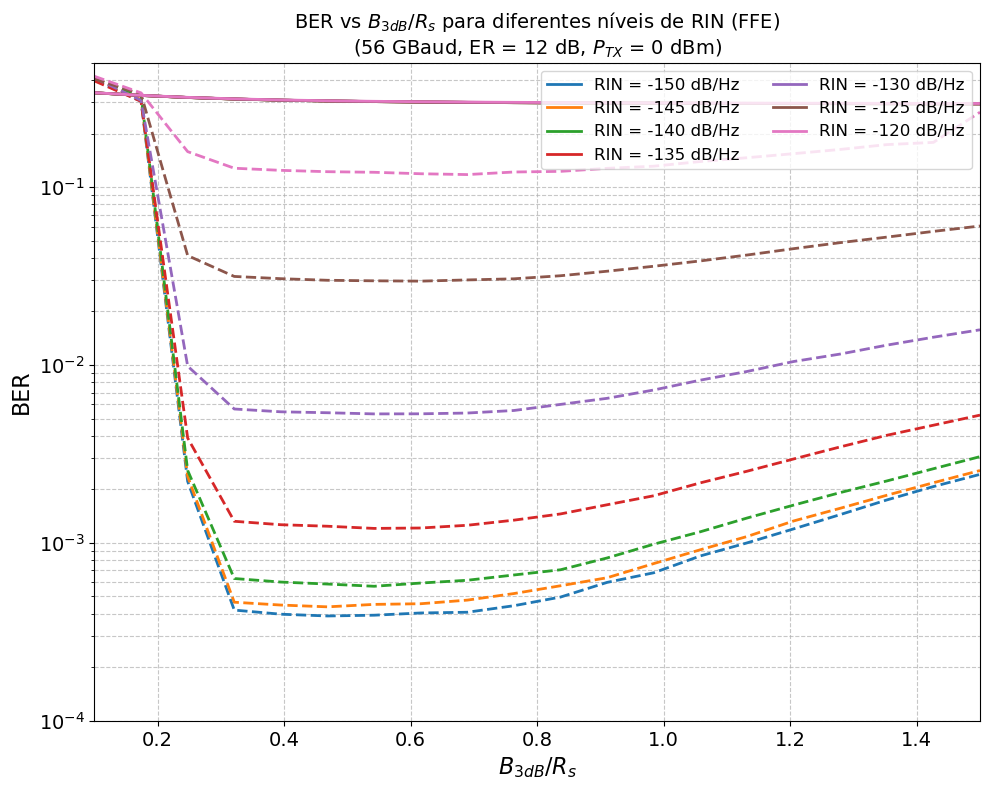

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
import scipy.special as sp
import time
import scipy.constants as const

# (Assumindo que suas funções 'calculate_oma_outer', 'calc_S_N', etc., e 
# o 'opticommpy' estão devidamente importados no seu ambiente)

# =================================================================
# 0. FUNÇÕES AUXILIARES (Q-Factor e BER PAM-M)
# =================================================================
def qfunc(x):
    return 0.5 * sp.erfc(x / np.sqrt(2))

def ber_from_snr_m_pam(snr_lin, M):
    return (2 * (M - 1) / (M * np.log2(M))) * qfunc(np.sqrt((3 * snr_lin) / (M**2 - 1)))

# =================================================================
# 1. PARÂMETROS GLOBAIS E EIXOS DA VARREDURA
# =================================================================
Rs = 56e9            # Artigo: 56 GBaud
P_avg_alvo = 1.0     # Artigo: PTX = 0 dBm (1 mW)
pTx_W = P_avg_alvo * 1e-3
M = 4                # Artigo: 4-PAM
er_db = 12.0         # Artigo: ER = 12 dB

N0 = 2e-19
c_speed = 299792458
lambda_c = 1310e-9 
fc = c_speed / lambda_c
kB = const.value("Boltzmann constant")
T_kelvin = 70 + 273.15

DAC_ADC = True

SpS_TX = 2 if DAC_ADC else 4 
Fs = Rs * SpS_TX
n_dac = 5 if DAC_ADC else 1
Res = 8
sim_Fs = n_dac * Fs
TX_Ts = 1 / Rs

n_order = 1 
SIM_N = 10000

# Eixos da Varredura
bw_ratios = np.linspace(0.1, 1.5, 20)
# Artigo: range de -150 dB/Hz até -120 dB/Hz
rin_values = [-150, -145, -140, -135, -130, -125, -120] 

# Estruturas para armazenar os resultados
ber_ana_results = {rin: [] for rin in rin_values}
ber_sim_results = {rin: [] for rin in rin_values}

# Eixos de frequência para o modelo analítico
SIM_fmax = sim_Fs/2 
f_analytical = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)
Tb = 1 / (Rs * 2)
Pulse_f = np.sinc(2 * Tb * f_analytical)

print("Iniciando Varredura. Aguarde...")
start_time = time.time()

# =================================================================
# 2. GERAÇÃO DO TRANSMISSOR (FORA DOS LOOPS PARA OTIMIZAÇÃO)
# =================================================================
paramBits = parameters()
paramBits.nBits = 1000000  # Aumentado para lidar melhor com o limite de 1e-5 BER
paramBits.mode = 'random'
paramBits.seed = 7
bits = bitSource(paramBits)

symb_Tx = modulateGray(bits, M, 'pam')
symb_Tx_up = upsample(symb_Tx, SpS_TX)

paramPulse = parameters()
paramPulse.pulseType = 'rect'
paramPulse.SpS = SpS_TX
pulse = pulseShape(paramPulse)

# Filtro de formatação de pulso
signal_Tx_base = firFilter(pulse, symb_Tx_up)

# Cálculos Base Analíticos
ER_lin = 10**(er_db/10)
x = (ER_lin - 1) / (ER_lin + 1)

OMA_outer = calculate_oma_outer(pTx_W, er_db)
Ps2 = calculate_ps2(pTx_W, M, OMA_outer)
S_th_array = calc_S_th(N0, f_analytical)
S_shot_array = calc_S_shot(pTx_W, 1.0, 1, 1, f_analytical)

# Normalização estrita do sinal para o range [-1, 1]
# Essa etapa substitui o drive complexo do MZM e garante espaçamento PAM perfeito
signal_Tx_norm_base = pnorm(signal_Tx_base)

if DAC_ADC:
    paramDAC = parameters()
    paramDAC.inFs = Fs            
    paramDAC.outFs = sim_Fs       
    paramDAC.nBits = Res         
    paramDAC.ENOB = paramDAC.nBits          
    paramDAC.Vpp = 2.0          
    paramDAC.AIF = True  
    signal_Tx_norm = dac(signal_Tx_norm_base, paramDAC)
else:
    signal_Tx_norm = signal_Tx_norm_base

f_sim = fftfreq(len(signal_Tx_norm), d=1/sim_Fs)

# =================================================================
# 3. LOOP PRINCIPAL (RIN -> B_3dB)
# =================================================================
for rin in rin_values:
    print(f"\n>> Processando RIN = {rin} dB/Hz")
    
    # Modelo Analítico: PSD do RIN
    S_RIN_global = calc_S_RIN(Ps2, rin, f_analytical)
    S_ADC = calc_S_ADC(paramDAC.Vpp, paramDAC.ENOB, Rs, f_analytical, 2*SIM_fmax)
    rin_lin = 10**(rin / 10)
    
    # --- TRANSMISSOR ÓPTICO IDEAL ---
    # 1. Gera a potência óptica IDEAL (amarrada perfeitamente ao OMA e ER)
    P_opt_ideal = pTx_W * (1 + x * signal_Tx_norm)
    
    # 2. Variância do RIN (conforme o modelo analítico e a frequência de amostragem)
    var_n_rin = (rin_lin / 2) * sim_Fs
    
    # 3. Geração de ruído real puramente de intensidade
    n_rin = np.random.normal(0, np.sqrt(var_n_rin), len(P_opt_ideal))
    
    # 4. Aplica o RIN à potência instantânea (np.maximum evita potências negativas)
    P_opt_com_rin = P_opt_ideal * np.maximum(1 + n_rin, 0.0)
    
    # 5. O fotodiodo extrai a corrente a partir do Campo Elétrico (E). 
    # Sendo I_pd proporcional a |E|^2, convertemos a potência em campo usando a raiz.
    signal_optTx = np.sqrt(P_opt_com_rin)
    
    signal_optTx_fft = fft(signal_optTx)
    
    for bw_ratio in bw_ratios:
        B_3dB = bw_ratio * Rs
        
        # --- MODELO ANALÍTICO ---
        H_ch_total_ana = superGauss(f_analytical, n=n_order, B_3dB=B_3dB) # Back-to-Back (sem H_CD)
        H_ch_sq_ana = np.abs(H_ch_total_ana)**2
        
        S_N_total = calc_S_N(S_RIN_global, S_shot_array, S_th_array, S_ADC, H_ch_sq_ana, True)
        S_N_f = get_spectral_snr(f_analytical, OMA_outer, Rs, Pulse_f, H_ch_total_ana, S_N_total)
        S_N_f = np.maximum(np.nan_to_num(S_N_f, nan=1e-30), 1e-30)
        
        SNR_folded = SNR_Folding(S_N_f, f_analytical, mu=2, Rs=Rs)
        safe_SNR = np.maximum(np.abs(SNR_folded), 1e-30) 
        SNR_f_interp = 10**(np.interp(f_int, f_analytical, 10 * np.log10(safe_SNR)) / 10)
        
        snr_ffe_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp + 1), x=f_int)) - 1
        ber_ana_results[rin].append(ber_from_snr_m_pam(snr_ffe_lin, M))
        
        # --- SIMULAÇÃO ---
        paramPD = parameters()
        paramPD.R = 1.0
        paramPD.Id = 1e-9                                    
        paramPD.RL = (4 * kB * T_kelvin) / N0 
        paramPD.Fs = sim_Fs
        paramPD.ideal = False
        paramPD.shotNoise = True
        paramPD.thermalNoise = True
        paramPD.currentSaturation = False
        paramPD.bandwidthLimitation = False
        paramPD.seed = 7
        
        # Passa o sinal óptico direto pro PD (Back-to-Back)
        PD_signalRx = photodiode(signal_optTx, paramPD)
        
        H_ch_sim = superGauss(f_sim, n=n_order, B_3dB=B_3dB)
        PD_signalRx_filtered = np.real(ifft(fft(PD_signalRx) * H_ch_sim))
        
        if DAC_ADC:
            paramAdc = parameters()
            paramAdc.inFs = sim_Fs
            paramAdc.outFs = Fs
            paramAdc.nBits = paramDAC.nBits
            paramAdc.ENOB = paramDAC.ENOB
            paramAdc.Vmax = np.max(np.abs(PD_signalRx_filtered))
            paramAdc.Vmin = -paramAdc.Vmax
            paramAdc.AAF = False 
            
            sigRx = adc(PD_signalRx_filtered, paramAdc)
            sigRx = firFilter(pulse, sigRx) 
        else:
            sigRx_alta_res = firFilter(pulse, PD_signalRx_filtered) 
            fator_decimacao = SpS_TX // 2
            sigRx = sigRx_alta_res[::fator_decimacao]
        
        nTrain = 100000
        
        paramFFE = parameters()
        paramFFE.nTaps = 200
        paramFFE.mu = 5e-4
        paramFFE.nTrain = nTrain
        paramFFE.SpS = 2
        paramFFE.M = M
        paramFFE.trainingMode = "fulltime"
        outFFE, _, _ = ffe(sigRx, symb_Tx, paramFFE)
        outFFE = pnorm(outFFE)

        discard = nTrain
        ber_ffe_sim, _, _ = fastBERcalc(outFFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')
        
        ber_sim_results[rin].append(ber_ffe_sim[0])

print(f"\nTempo Total: {(time.time() - start_time)/60:.2f} min")

# =================================================================
# 4. PLOTAGEM DO GRÁFICO (Estilo do Artigo)
# =================================================================
plt.figure(figsize=(10, 8))

# Cores para cada RIN para manter a consistência entre linha contínua e tracejada
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, rin in enumerate(rin_values):
    c = colors[i % len(colors)]
    # Curva Analítica (Sólida)
    plt.semilogy(bw_ratios, ber_ana_results[rin], '-', color=c, linewidth=2, label=f'RIN = {rin} dB/Hz')
    # Curva Simulação (Tracejada)
    plt.semilogy(bw_ratios, ber_sim_results[rin], '--', color=c, linewidth=2)

plt.xlabel(r'$B_{3dB}/R_s$', fontsize=16)
plt.ylabel('BER', fontsize=16)
plt.ylim(1e-4, 0.5)
plt.xlim(0.1, 1.5)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.tick_params(axis='both', labelsize=14)

# Ajuste da legenda para ficar semelhante à da imagem
plt.legend(fontsize=12, loc='upper right', ncol=2)

plt.title('BER vs $B_{3dB}/R_s$ para diferentes níveis de RIN (FFE)\n(56 GBaud, ER = 12 dB, $P_{TX}$ = 0 dBm)', fontsize=14)
plt.tight_layout()
plt.show()

Iniciando Varredura. Aguarde...

DIAGNÓSTICO DO SINAL ÓPTICO (SIMULAÇÃO vs TEORIA)
OMA Teórico:   1.7626e-03 W
OMA Simulado:  1.7626e-03 W
ER Teórico:    12.00 dB
ER Simulado:   12.00 dB

>> Processando RIN = -150 dB/Hz

----------------------------------------
DIAGNÓSTICO DAS VARIÂNCIAS DE RUÍDO (DOMÍNIO DO TEMPO)
Variância RIN Média:  3.2057e-10 A^2
Variância Térmica:    4.4800e-08 A^2
Variância Shot Média: 7.1763e-11 A^2
----------------------------------------

>> Processando RIN = -145 dB/Hz
>> Processando RIN = -140 dB/Hz
>> Processando RIN = -135 dB/Hz
>> Processando RIN = -130 dB/Hz
>> Processando RIN = -125 dB/Hz
>> Processando RIN = -120 dB/Hz

Tempo Total: 9.31 min


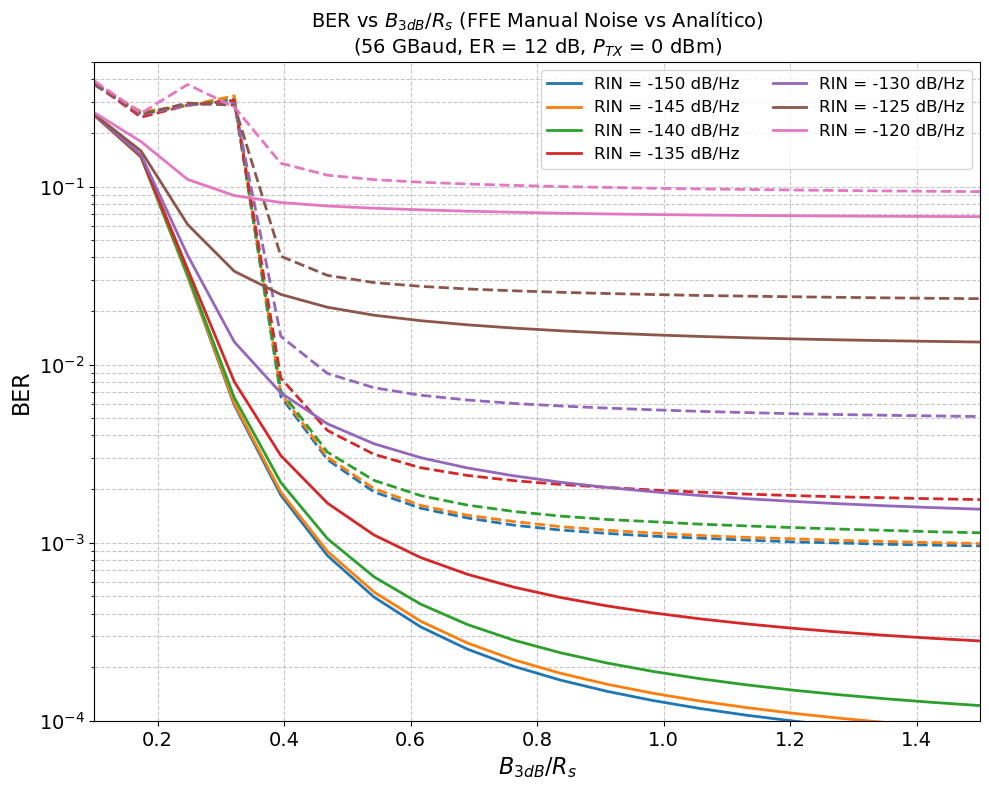

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
import scipy.special as sp
import time
import scipy.constants as const

# (Assumindo que suas funções do OpticommPy e analíticas estão no ambiente)

# =================================================================
# 0. FUNÇÕES AUXILIARES (Q-Factor e BER PAM-M)
# =================================================================
def qfunc(x):
    return 0.5 * sp.erfc(x / np.sqrt(2))

def ber_from_snr_m_pam(snr_lin, M):
    return (2 * (M - 1) / (M * np.log2(M))) * qfunc(np.sqrt((3 * snr_lin) / (M**2 - 1)))

# =================================================================
# 1. PARÂMETROS GLOBAIS E EIXOS DA VARREDURA
# =================================================================
Rs = 56e9            # Artigo: 56 GBaud
P_avg_alvo = 1.0     # Artigo: PTX = 0 dBm (1 mW)
pTx_W = P_avg_alvo * 1e-3
M = 4                # Artigo: 4-PAM
er_db = 12.0         # Artigo: ER = 12 dB

N0 = 2e-19
c_speed = 299792458
lambda_c = 1310e-9 
fc = c_speed / lambda_c
kB = const.value("Boltzmann constant")
T_kelvin = 70 + 273.15
q_e = const.e  # Carga do elétron

DAC_ADC = False

SpS_TX = 8
Fs = Rs * SpS_TX
n_dac = 5 if DAC_ADC else 1
Res = 8
sim_Fs = n_dac * Fs
TX_Ts = 1 / Rs

n_order = 1 
SIM_N = 10000

# Eixos da Varredura
bw_ratios = np.linspace(0.1, 1.5, 20)
# Artigo: range de -150 dB/Hz até -120 dB/Hz
rin_values = [-150, -145, -140, -135, -130, -125, -120] 

# Estruturas para armazenar os resultados
ber_ana_results = {rin: [] for rin in rin_values}
ber_sim_results = {rin: [] for rin in rin_values}

# Eixos de frequência para o modelo analítico
SIM_fmax = 3e12
f_analytical = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)
Tb = 1 / (Rs * 2)
Pulse_f = np.sinc(2 * Tb * f_analytical)

print("Iniciando Varredura. Aguarde...")
start_time = time.time()

# =================================================================
# 2. GERAÇÃO DO TRANSMISSOR IDEAL
# =================================================================
paramBits = parameters()
paramBits.nBits = 5000000  
paramBits.mode = 'random'
paramBits.seed = 7
bits = bitSource(paramBits)

symb_Tx = modulateGray(bits, M, 'pam')
symb_Tx_up = upsample(symb_Tx, SpS_TX)

paramPulse = parameters()
paramPulse.pulseType = 'rect'
paramPulse.SpS = SpS_TX
pulse = pulseShape(paramPulse)

signal_Tx_base = firFilter(pulse, symb_Tx_up)

# Cálculos Base Analíticos
ER_lin = 10**(er_db/10)
x = (ER_lin - 1) / (ER_lin + 1)

OMA_outer = calculate_oma_outer(pTx_W, er_db)
Ps2 = calculate_ps2(pTx_W, M, OMA_outer)
S_th_array = calc_S_th(N0, f_analytical)
S_shot_array = calc_S_shot(pTx_W, 1.0, 1, 1, f_analytical)

# Normalização estrita do sinal [-1, 1]
signal_Tx_norm_base = signal_Tx_base / np.max(np.abs(signal_Tx_base))

if DAC_ADC:
    paramDAC = parameters()
    paramDAC.inFs = Fs            
    paramDAC.outFs = sim_Fs       
    paramDAC.nBits = Res         
    paramDAC.ENOB = paramDAC.nBits          
    paramDAC.Vpp = 2.0         
    paramDAC.AIF = True  
    signal_Tx_norm = dac(signal_Tx_norm_base, paramDAC)
else:
    signal_Tx_norm = signal_Tx_norm_base

f_sim = fftfreq(len(signal_Tx_norm), d=1/sim_Fs)

# --- VERIFICAÇÃO DE OMA E ER ---
P_opt_ideal = pTx_W * (1 + x * signal_Tx_norm)
sim_OMA = np.max(P_opt_ideal) - np.min(P_opt_ideal)
sim_ER_dB = 10 * np.log10(np.max(P_opt_ideal) / np.min(P_opt_ideal))

print("\n" + "="*50)
print("DIAGNÓSTICO DO SINAL ÓPTICO (SIMULAÇÃO vs TEORIA)")
print(f"OMA Teórico:   {OMA_outer:.4e} W")
print(f"OMA Simulado:  {sim_OMA:.4e} W")
print(f"ER Teórico:    {er_db:.2f} dB")
print(f"ER Simulado:   {sim_ER_dB:.2f} dB")
print("="*50 + "\n")

# =================================================================
# 3. LOOP PRINCIPAL (RIN -> B_3dB)
# =================================================================
for rin_idx, rin in enumerate(rin_values):
    print(f">> Processando RIN = {rin} dB/Hz")
    
    S_RIN_global = calc_S_RIN(Ps2, rin, f_analytical)
    rin_lin = 10**(rin / 10)
    
    # Adição do RIN
    var_n_rin = (rin_lin / 2) * sim_Fs
    n_rin = np.random.normal(0, np.sqrt(var_n_rin), len(P_opt_ideal))
    P_opt_com_rin = P_opt_ideal * np.maximum(1 + n_rin, 0.0)
    
    # --- RECEPTOR: FOTODIODO MANUAL (CONVERSÃO P -> I + RUÍDOS) ---
    R_pd = 1.0 
    I_pd = R_pd * P_opt_com_rin
    
    # 1. Ruído Térmico (PSD N0 unipolar -> Variância = N0 * sim_Fs / 2)
    var_th = N0 * (sim_Fs / 2)
    i_th = np.random.normal(0, np.sqrt(var_th), len(I_pd))
    
    # 2. Ruído de Disparo (Dependente do sinal instantâneo)
    # Variância = 2 * q * I * (sim_Fs / 2) = q * I * sim_Fs
    var_shot = q_e * I_pd * sim_Fs
    i_shot = np.random.normal(0, np.sqrt(var_shot))
    
    # Corrente RX Total
    PD_signalRx = I_pd + i_shot + i_th
    
    # --- DIAGNÓSTICO DE RUÍDO (Printa apenas no primeiro RIN) ---
    if rin_idx == 0:
        print("\n" + "-"*40)
        print("DIAGNÓSTICO DAS VARIÂNCIAS DE RUÍDO (DOMÍNIO DO TEMPO)")
        print(f"Variância RIN Média:  {np.mean((P_opt_ideal * n_rin)**2):.4e} A^2")
        print(f"Variância Térmica:    {var_th:.4e} A^2")
        print(f"Variância Shot Média: {np.mean(var_shot):.4e} A^2")
        print("-"*40 + "\n")

    for bw_ratio in bw_ratios:
        B_3dB = bw_ratio * Rs
        
        # --- MODELO ANALÍTICO ---
        H_ch_total_ana = superGauss(f_analytical, n=n_order, B_3dB=B_3dB)
        H_ch_sq_ana = np.abs(H_ch_total_ana)**2
        
        S_N_total = (np.abs(Pulse_f)**2)*calc_S_N(S_RIN_global, S_shot_array, S_th_array, 0, H_ch_sq_ana, False)
        S_N_f = (np.abs(Pulse_f)**2)*get_spectral_snr(f_analytical, OMA_outer, Rs, Pulse_f, H_ch_total_ana, S_N_total)
        S_N_f = np.maximum(np.nan_to_num(S_N_f, nan=1e-30), 1e-30)
        
        SNR_folded = SNR_Folding(S_N_f, f_analytical, mu=2, Rs=Rs)
        safe_SNR = np.maximum(np.abs(SNR_folded), 1e-30) 
        SNR_f_interp = 10**(np.interp(f_int, f_analytical, 10 * np.log10(safe_SNR)) / 10)
        
        snr_ffe_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp + 1), x=f_int)) - 1
        ber_ana_results[rin].append(ber_from_snr_m_pam(snr_ffe_lin, M))
        
        # --- SIMULAÇÃO ---
        H_ch_sim = superGauss(f_sim, n=n_order, B_3dB=B_3dB)
        PD_signalRx_filtered = np.real(ifft(fft(PD_signalRx) * H_ch_sim))
        paramdec = parameters()
        paramdec.SpSin = SpS_TX
        paramdec.SpSout = 2
        
        if DAC_ADC:
            paramAdc = parameters()
            paramAdc.inFs = sim_Fs
            paramAdc.outFs = Fs
            paramAdc.nBits = paramDAC.nBits
            paramAdc.ENOB = paramDAC.ENOB
            paramAdc.Vmax = np.max(np.abs(PD_signalRx_filtered))
            paramAdc.Vmin = -paramAdc.Vmax
            paramAdc.AAF = False 
            
            sigRx = adc(PD_signalRx_filtered, paramAdc)
            sigRx = firFilter(pulse, sigRx) 
        else:
            sigRx = firFilter(pulse, PD_signalRx_filtered)
            sigRx = decimate(sigRx, paramdec) 
        
        nTrain = 100000
        
        paramFFE = parameters()
        paramFFE.nTaps = 200
        paramFFE.mu = 4e-5
        paramFFE.nTrain = nTrain
        paramFFE.SpS = 2
        paramFFE.M = M
        paramFFE.trainingMode = "fulltime"
        outFFE, _, _ = ffe(sigRx, symb_Tx, paramFFE)
        outFFE = pnorm(outFFE)

        discard = nTrain
        ber_ffe_sim, _, _ = fastBERcalc(outFFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')
        
        ber_sim_results[rin].append(ber_ffe_sim[0])

print(f"\nTempo Total: {(time.time() - start_time)/60:.2f} min")

# =================================================================
# 4. PLOTAGEM DO GRÁFICO
# =================================================================
plt.figure(figsize=(10, 8))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, rin in enumerate(rin_values):
    c = colors[i % len(colors)]
    plt.semilogy(bw_ratios, ber_ana_results[rin], '-', color=c, linewidth=2, label=f'RIN = {rin} dB/Hz')
    plt.semilogy(bw_ratios, ber_sim_results[rin], '--', color=c, linewidth=2)

plt.xlabel(r'$B_{3dB}/R_s$', fontsize=16)
plt.ylabel('BER', fontsize=16)
plt.ylim(1e-4, 0.5)
plt.xlim(0.1, 1.5)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=12, loc='upper right', ncol=2)
plt.title('BER vs $B_{3dB}/R_s$ (FFE Manual Noise vs Analítico)\n(56 GBaud, ER = 12 dB, $P_{TX}$ = 0 dBm)', fontsize=14)
plt.tight_layout()
plt.show()